In [115]:
# Example: connect to a MySQL server over an SSH tunnel and load results into a pandas DataFrame
# Requires: pip install sshtunnel mysql-connector-python pandas
from sqlalchemy import create_engine
import pandas as pd

DATE = '2026-04-10'
DAYS_LOOKBACK = 0

SQL_QUERY = f"""
    SELECT direction, hour, minute, delay, line FROM kruppallee.realtime_departures 
    WHERE
        date <= '{DATE}'
        AND date >= DATE_SUB('{DATE}', INTERVAL {DAYS_LOOKBACK} DAY)
        AND line in ('107', '108')
    ORDER BY hour, minute
"""

DB_HOST = 'raspberrypi'  # from the SSH server's perspective
DB_PORT = 3306
DB_USER = 'python'
DB_PASSWORD = 'h6s73hb378f7wh'
DB_NAME = 'kruppallee'


# Build SQLAlchemy engine for MySQL
engine = create_engine(
    f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

df = pd.read_sql(SQL_QUERY, con=engine)
df = df[df['delay'] < 30]  # filter for delayed departures
df.head()

,direction,hour,minute,delay,line
0,Essen Bredeney,4,27,0,108
1,Essen Altenessen Bf,4,40,0,108
2,Essen Bredeney,4,47,0,108
3,Essen Altenessen Bf,5,0,0,108
4,Essen Bredeney,5,7,0,108


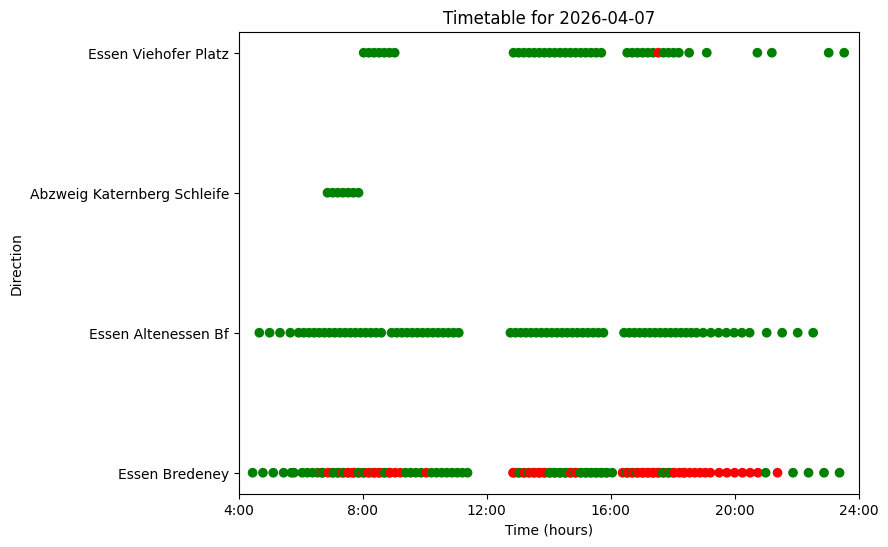

In [43]:
# create a timetable display
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))
times = df['hour'] + df['minute'] / 60

colors = ['red' if delay > 0 else 'green' for delay in df['delay']]
ax.scatter(times, df['direction'], c=colors)
ax.set_xlabel('Time (hours)')
ax.set_xlim(4, 24)
ax.set_xticks(range(4, 25, 4))
ax.set_xticklabels([f'{int(t)}:00' for t in range(4,25,4)])
ax.set_ylabel('Direction')
ax.set_title(f'Timetable for {DATE}')
plt.show()

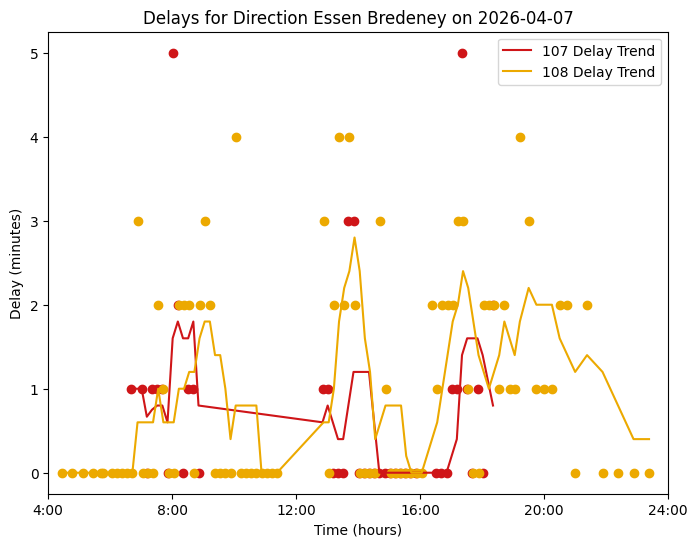

In [45]:
# create a plot to show delays over time
fig, ax = plt.subplots(figsize=(8, 6))
# filter for direction Essen Bredeney and the lines 107 and 108
df_107 = df[(df['direction'] == 'Essen Bredeney') & (df['line'] == '107')].copy()
df_108 = df[(df['direction'] == 'Essen Bredeney') & (df['line'] == '108')].copy()
times = df['hour'] + df['minute'] / 60
times_107 = df_107['hour'] + df_107['minute'] / 60
times_108 = df_108['hour'] + df_108['minute'] / 60
ax.scatter(times_107, df_107['delay'], c='#cf1518')
ax.scatter(times_108, df_108['delay'], c='#eca900')

# add a floating average smooth line to show the trend
df_107['delay_smooth'] = df_107['delay'].rolling(window=5*(DAYS_LOOKBACK+1), min_periods=1).mean()
df_108['delay_smooth'] = df_108['delay'].rolling(window=5*(DAYS_LOOKBACK+1), min_periods=1).mean()
ax.plot(times_107, df_107['delay_smooth'], color='#cf1518', label='107 Delay Trend')
ax.plot(times_108, df_108['delay_smooth'], color='#eca900', label='108 Delay Trend')
ax.set_xlabel('Time (hours)')
ax.set_xlim(4, 24)
ax.set_xticks(range(4, 25, 4))
ax.set_xticklabels([f'{int(t)}:00' for t in range(4,25,4)])
ax.set_ylabel('Delay (minutes)')
ax.legend()
ax.set_title(f'Delays for Direction Essen Bredeney on {DATE}')
plt.show()

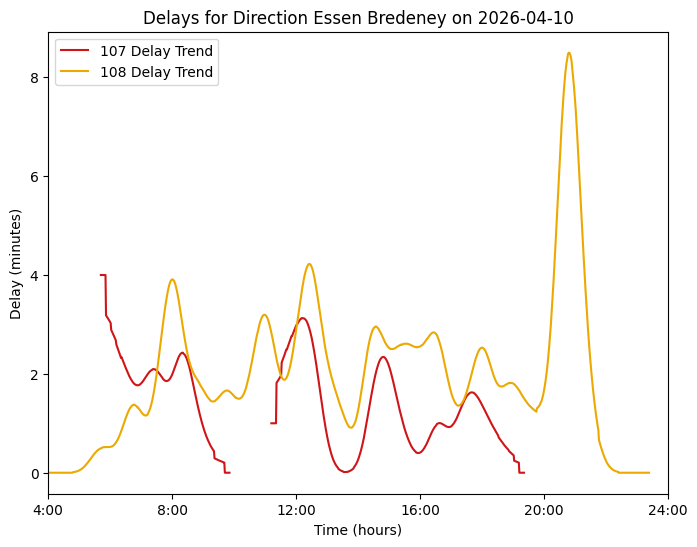

In [116]:
# create a plot to show delays over time
fig, ax = plt.subplots(figsize=(8, 6))
# filter for direction Essen Bredeney and the lines 107 and 108
df_107 = df[(df['direction'] == 'Essen Bredeney') & (df['line'] == '107')].copy()
df_108 = df[(df['direction'] == 'Essen Bredeney') & (df['line'] == '108')].copy()
times_107 = df_107['hour'] + df_107['minute'] / 60
times_108 = df_108['hour'] + df_108['minute'] / 60
# ax.scatter(times_107, df_107['delay'], c='#cf1518')
# ax.scatter(times_108, df_108['delay'], c='#eca900')
times_107 = times_107 * 60  # convert to minutes
times_108 = times_108 * 60  # convert to minutes

# add a floating average smooth line to show the trend
smooth = pd.DataFrame({'minute': range(0, 24 * 60)})  # every minute
smooth['delay_107'] = df_107.set_index(times_107)['delay'].reindex(smooth['minute'])
smooth['delay_107'] = smooth['delay_107'].rolling(window=120, win_type='gaussian', min_periods=1, center=True).mean(std=20)
smooth['delay_108'] = df_108.set_index(times_108)['delay'].reindex(smooth['minute'])
smooth['delay_108'] = smooth['delay_108'].rolling(window=120, win_type='gaussian', min_periods=1, center=True).mean(std=20)
smooth['time'] = smooth['minute'] / 60
ax.plot(smooth['time'], smooth['delay_107'], color='#cf1518', label='107 Delay Trend')
ax.plot(smooth['time'], smooth['delay_108'], color='#eca900', label='108 Delay Trend')
ax.set_xlabel('Time (hours)')
ax.set_xlim(4, 24)
ax.set_xticks(range(4, 25, 4))
ax.set_xticklabels([f'{int(t)}:00' for t in range(4,25,4)])
ax.set_ylabel('Delay (minutes)')
ax.legend()
ax.set_title(f'Delays for Direction Essen Bredeney on {DATE}')
plt.show()

[[], [], [], [], [], ['20', '27', '40', '42', '47', '56'], ['06', '13', '41 (1 min)', '43 (3 min)', '46', '51', '52', '53', '56'], ['01', '02', '03 (2 min)', '06', '11', '12', '13', '16', '21', '22', '23', '26', '32', '33', '36', '41', '42', '43 (3 min)', '46', '51', '52', '53', '56'], ['01', '02', '06', '12', '13', '22', '23', '26', '32', '33', '36', '42', '43', '53'], ['13 (1 min)', '16', '23 (1 min)', '26', '33 (1 min)', '36', '43', '46', '53', '56'], ['03', '06', '13 (2 min)', '16', '23', '26', '33', '36', '43 (2 min)', '46', '53', '56'], ['03 (3 min)', '06', '13 (4 min)', '16', '23', '26', '33', '36', '43', '46', '53 (2 min)', '56'], ['03', '06', '11', '13 (3 min)', '16', '21', '22', '23 (4 min)', '26', '31', '32', '33 (2 min)', '36', '41', '42', '43 (2 min)', '46', '51 (1 min)', '52', '53 (2 min)', '56'], ['01 (1 min)', '02', '03 (1 min)', '06', '11 (2 min)', '12', '13 (3 min)', '16', '21 (1 min)', '22', '23 (1 min)', '26', '31 (4 min)', '32', '33 (4 min)', '36', '41', '42', '43'

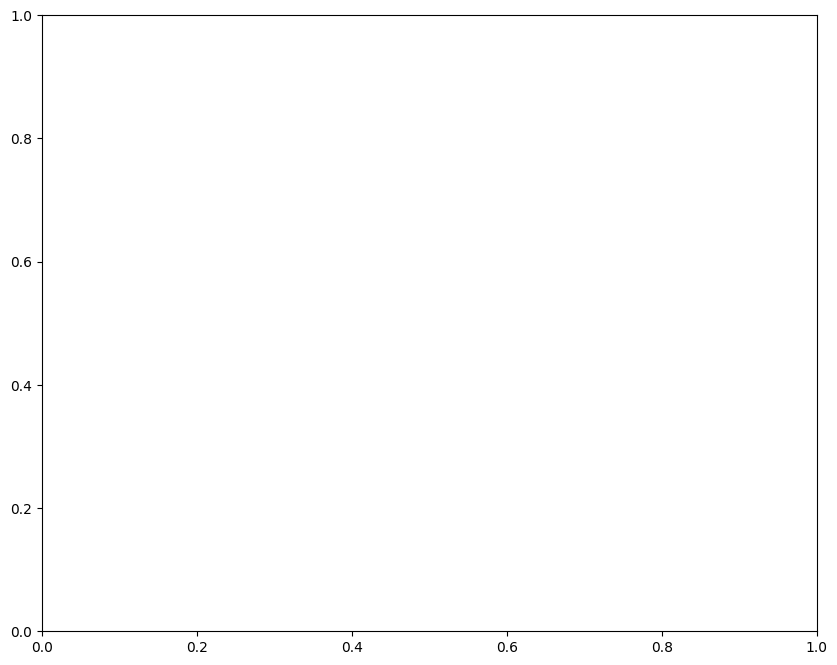

In [4]:
# create a table like timetable display
# in the rows are the hours, in the columns all the departures within that hour
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
times = df['hour'] + df['minute'] / 60

# create a table-like display
table_data = []
for hour in range(24):
    row = []
    hour_data = df[df['hour'] == hour]
    for minute in range(60):
        minute_data = hour_data[hour_data['minute'] == minute]
        if not minute_data.empty:
            delay = minute_data['delay'].values[0]
            cell_text = f"{minute:02d} ({delay} min)" if delay > 0 else f"{minute:02d}"
            row.append(cell_text)
    table_data.append(row)

print(table_data)